<a href="https://colab.research.google.com/github/HKozuka/Convolutional-Neural-Network-for-Sound-Classification/blob/main/ConvNeXt_sound_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Supervised Fine-Tuning (post-training) a ConvNeXt convolutional neural network to complete sound classification tasks on audio clips**

In [ ]:
## IMPORTANT

import sys
IS_COLAB = 'google.colab' in sys.modules
if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/cs189/hw/hw4
    %pip install -r ./requirements.txt
    !pip install -U kaleido plotly soundfile torchcodec
    import kaleido
    kaleido.get_chrome_sync()

import plotly.io as pio
pio.renderers.default = pio.renderers.default + "+png"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/cs189/hw/hw4
  Cloning https://github.com/BerkeleyML/otter-grader-189.git (to revision master) to /tmp/pip-install-qdurup8t/otter-grader_5df84c0443c8494e9b85347e1df1df68
  Running command git clone --filter=blob:none --quiet https://github.com/BerkeleyML/otter-grader-189.git /tmp/pip-install-qdurup8t/otter-grader_5df84c0443c8494e9b85347e1df1df68
  Resolved https://github.com/BerkeleyML/otter-grader-189.git to commit 35e43fdf64a55f4b9222d7b531890fb7d5cb498c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached plotly-6.6.0-py3-none-any.whl.metadata (8.5 kB)
Using cached plotly-6.6.0-py3-none-any.whl (9.9 MB)
  Using cached kaleido-1.2.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached choreographer-1.2.1-py3-none-any.whl.metadata (6.8 kB)
  U

In [ ]:
import os
import random

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import plotly
import plotly.graph_objects
import plotly.subplots
import torch
import torch.nn as nn
from torch.optim import AdamW
import torchaudio
import torchvision
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision.models import convnext_base, ConvNeXt_Base_Weights
from transformers import AutoTokenizer, AutoModel

In [ ]:
# Do not change the random seed values!

def set_seed():
    """
    Set the seed for all random number generators
    """
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Set random seeds for reproducible results
SEED = 42
set_seed()

def get_device():
    """
    Use hardware accelerator if available
    """
    if torch.accelerator.is_available():
        device = torch.accelerator.current_accelerator()
    else:
        device = "cpu"
    print(f"Using device: {device}")
    return device

device = get_device()

IS_GRADING_ENV = os.getenv("IS_GRADING_ENV") == "true"

Using device: cuda


<!-- END QUESTION -->

# Matrices are All You Need - ConvNeXt Sound Classification

Similar to how we can use transformers to encode and decode anything that can be represented as a sequence of numerical tokens, we'll now also explore how creating clever matrix representations can let computer vision models tackle fascinating problems.

At first glance (or first listen), sound might seem like a very different modality from the image data that computer vision models work with. However, by thinking outside the box, we can actually transform the task of sound classification into the task of image classification.

While we're only going to be exploring how to apply computer vision models to sound classification, the possibilities are endless: imagine turning network signals into an graph to detect cybersecurity anomalies, or using meterology data to predict hurricane paths!

First, we'll load the UrbanSound8k dataset.

## UrbanSound8k

[UrbanSound8k Kaggle Dataset](https://www.kaggle.com/datasets/chrisfilo/urbansound8k?select=UrbanSound8K.csv)

The UrbanSound8K dataset consists of 8,732 short audio clips, each lasting up to 4 seconds, collected from real-world urban environments. Every clip is labeled with one of 10 common urban sound classes, such as car horn, dog bark, siren, jackhammer, and more. The dataset also includes a csv with additional metadata about each sound file,including the sound class, the recording fold, and additional details to support supervised learning and evaluation.


The dataset follows a specific naming convention:
Each audio file is named as
`[fsID]-[classID]-[occurrenceID]-[sliceID].wav`
where:
* `fsID`: a unique identifier for the original recording,
* `classID`: an integer representing the sound class (0 for air_conditioner, 1 for car horn, etc.),
* `occurrenceID`: which instance of that sound in the field recording,
* `sliceID`: identifies the particular slice within the occurrence.

For example, `100032-3-0-0.wav` is the first slice `(0)` of the first occurrence `(0)` of the sound class `3` (which corresponds to “dog bark”) from original recording ID `100032`.

For our purposes, we'll only need the `classID` substring from the file names!

### What is Cross-Validation?
The UrbanSound8K dataset is organized into 10 separate “folds”, which are different partitions of the data. Each clip in the dataset is assigned to one of these folds (from 1 to 10), which helps support **cross-validation** experiments for more robust model evaluation. In typical practice, a few folds are used for training, and the remaining ones for validation or testing, rotating which folds are used for each split.

**Cross-validation** is a technique used to reliably estimate how well a machine learning model will perform on new, unseen data. Instead of training and testing our model on just one split of the data, we divide our dataset into several parts (called folds) and rotate using different folds for training and testing. This way, we get multiple performance measurements that can be averaged for a fairer estimate.
* Suppose we have our dataset split into 10 folds (as in UrbanSound8K). In each "round" of cross-validation, we use 9 folds for training and 1 fold for testing. We repeat this ten times, each time with a different fold held out as your test set.
* This ensures every example gets used once for testing and multiple times for training.

For this assignment, we’ll only use the audio clips from fold 1. This keeps things simple, enabling faster prototyping and easier debugging as you work through the fundamentals of urban sound classification.

Acknowledgements: J. Salamon, C. Jacoby and J. P. Bello, ["A Dataset and Taxonomy for Urban Sound Research"](https://dl.acm.org/doi/10.1145/2647868.2655045), 22nd ACM International Conference on Multimedia, Orlando USA, Nov. 2014.

In [ ]:
# Unzip the training data to data/fold1_train. This may take a few minutes!
!unzip -o -q /content/drive/MyDrive/cs189/hw/hw4/data/urbansound8k_fold1_train.zip -d /content/drive/MyDrive/cs189/hw/hw4/data/fold1_train

unzip:  cannot find or open /content/drive/MyDrive/cs189/hw/hw4/data/urbansound8k_fold1_train.zip, /content/drive/MyDrive/cs189/hw/hw4/data/urbansound8k_fold1_train.zip.zip or /content/drive/MyDrive/cs189/hw/hw4/data/urbansound8k_fold1_train.zip.ZIP.


Let's listen to one of the audio clips we just downloaded. According to the UrbanSound8k dataset's description, these are the mappings of the `classID`s to the sound's class:
>```python
>class_id_to_sound = {
>    0: "air_conditioner",
>    1: "car_horn",
>    2: "children_playing",
>    3: "dog_bark",
>    4: "drilling",
>    5: "engine_idling",
>    6: "gun_shot",
>    7: "jackhammer",
>    8: "siren",
>    9: "street_music"
> }
>```

Feel free to change the path of the audio file to listen to different clips!

## Creating Spectrograms with Torchaudio

Besides being an awesome Python library for building neural networks, PyTorch also has an official audio processing library called **Torch audio** that comes with handy tools for loading, transforming, and analyzing audio data in deep learning applications. **Torchaudio** is designed to work seamlessly with PyTorch and offers GPU acceleration for audio processing tasks.

The `torchaudio.transforms` module contains common audio feature extraction functions such as spectrograms. These trasnforms can convert raw waveforms into numeric represetnations suitable for neural networks.

The `torchaudio.transforms.Spectrogram` transform converts a raw audio waveform (a 1D array of amplitude values) into a spectrogram. This transformation is useful because it turns sound into an image-like format, which can be processed by image-based machine learning models.

**Spectrograms** are a 2D representation of how the frequency content of the audio changes over time.
* The spectrograms are generated by applying the **Short-Time Fourier Transform (STFT)** to overlapping windows of the audio signal. The result is a matrix where:
    * The x-axis represents time (split into small chunks called time bins)
    * The y-axis represents frequency (split into frequency bins)
    * The values in the matrix show the strength (amplitude) of each frequency at each time
* The `n_fft` parameter stands for "number of FFT points". It controls the size of the window (in samples) used for each Fourier Transform when creating the spectrogram. In other words, it determines how many audio samples are analyzed at a time to compute the frequency content. For example, `n_fft=1024` means each window of 1024 samples is transformed to analyze its frequency content. The choice of `n_fft` is a trade-off between how precisely you want to see changes in frequency versus changes in time.


In the following code:
1. We load an audio file using `torchaudio.load`, which returns the waveform and the rate at which the audio was sampled.
2. Some of the audio clips are stereo (meaning they have 2 audio channels). In those cases, we average the 2 chanenls into a single (mono) channel for easier processing.
3. Then, we use the spectrogram transform to extract a spectrogram of the audio.
4. Finally, we plot the spectrogram using `matplotlib`
    1. Note: The raw values in the spectrogram represent the power (or energy) of each frequency at each time. However, these power values can vary by several orders of magnitude; some frequencies are much louder than others, and the differences can be huge. Taking the log of the power values is a common practice in signal processing to make the scale easier to interpret. Each step in the y-axis corresponds to doubling in power. This is why in the code, we plot `spec.log2`.

In [ ]:
pip install torchcodec

Spectrogram shape: torch.Size([1, 513, 376])


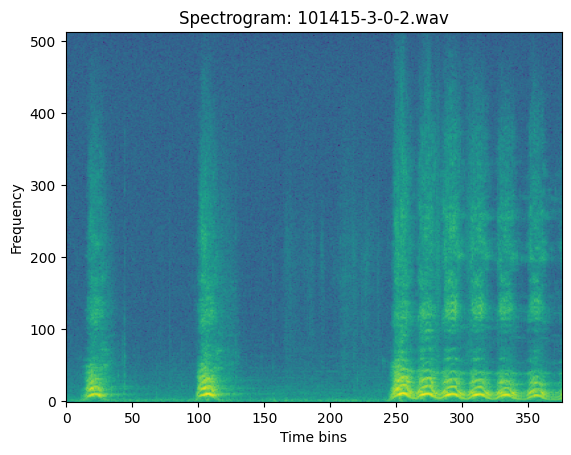

In [ ]:
spectrogram_transform = torchaudio.transforms.Spectrogram(n_fft=1024, normalized=True)

class_id_to_sound = {
    0: "air_conditioner",
    1: "car_horn",
    2: "children_playing",
    3: "dog_bark",
    4: "drilling",
    5: "engine_idling",
    6: "gun_shot",
    7: "jackhammer",
    8: "siren",
    9: "street_music"
}

audio_file = '/content/drive/MyDrive/cs189/hw/hw4/data/fold1_train/101415-3-0-2.wav'

try:
    # Read WAV file
    waveform, sample_rate = torchaudio.load(audio_file)

    # Converts stero to mono by averaging channels. Shape becomes [1, num_samples]
    waveform = waveform.mean(dim=0, keepdim=True)

    # Transform the waveform into a spectrogram
    spec = spectrogram_transform(waveform) # torch.Tensor of shape [1, freq_bins, time_bins]

    # Print the shape of the spectrogram
    print(f"Spectrogram shape: {spec.shape}") # shape [num_frequencies, num_time_bins]

    # Visualize the spectrogram
    plt.figure()
    plt.imshow(spec.log2()[0, :, :].numpy(), aspect='auto', origin='lower') # origin = 'lower' sets input[0, 0] at bottom left
    plt.title(f"Spectrogram: {audio_file.split('/')[-1]}")
    plt.xlabel("Time bins")
    plt.ylabel("Frequency")
    plt.show()
except Exception as e:
    print(f"Error processing {audio_file}: {e}")

## Creating a Custom Dataset of our Spectrograms

We will implement a custom PyTorch Dataset for audio spectrogram classification. Since our audio files that we will be using for training are stored as `.wav` files inside a folder, this dataset will load .wav audio files, convert each to a spectrogram image, and extract the class label from the file name.

Implemented the `__len__` and `__getitem__` methods of the SpectrogramDataset
1. Implement the `__len__` method, which returns the total number of samples in the Dataset.
2. Implement the `__getitem__` method.
    1. If `return_targets` is `True`, parse the `filename` to get the requested sample's target class. Convert this into a torch.Tensor with `dtype=torch.long`. We will use `return_targets` when creating a training dataset for our model, but when we make test predictions on a test set, we won't have provided targets/labels to instantiate our Dataset with.
3. Load the waveform using `torchaudio.load`.
4. If the audio has 2 stereo channels, average them into a single-channel mono waveform.
5. Generate a spectrogram of the waveform using the class's `spectrogram_transform`.
6. Computer vision models often expect 3-channel input images. The spectrogram only has 1 channel, but we can copy the spectrogram into 3 different channels. Repeat the spectrogram across the first (channel) dimension into a new tensor with shape `(3, H, W)`.
7. If provided, apply additional transformations to the spectrogram.
8. Return the processed spectrogram image and corresponding label.

In [ ]:
class SpectrogramDataset(Dataset):
    def __init__(self, audio_dir, transforms=None, spectrogram_transform=None, return_targets=True):
        super().__init__()
        self.audio_dir = audio_dir # Folder where the audio files will be located
        self.transforms = transforms # Additional image transforms
        self.spectrogram_transform = spectrogram_transform or torchaudio.transforms.Spectrogram(n_fft=1024, normalized=True)
        self.return_targets = return_targets  # Whether to return targets or not when __get_item__ is called
        try:
            # Get file paths of all .wav files in the provided directory
            self.file_paths = [f for f in os.listdir(audio_dir) if f.endswith('.wav')]
        except Exception as e:
            print(f"Error accessing files at {audio_dir}: {e}")
            self.file_paths = []

    def __len__(self):
        # Return the number of samples in the dataset
        return len(self.file_paths)

    def __getitem__(self, index):
        # Get the file name by index
        file_name = self.file_paths[index]

        # Construct the path to the requested audio file
        filepath = os.path.join(self.audio_dir, file_name)

        # Extract the target class_id from the file path if return_targets is True
        # Files are stored in the format [freesoundID]-[classID]-[occurrenceID]-[sliceID].wav
        # Don't forget to cast the class_id to dtype=torch.long for loss functions!
        if self.return_targets:
            target = file_name.split('-')[1]
            target = torch.tensor(int(target), dtype=torch.long)

        try:
            # Load the audio file located at `filepath`
            waveform, sample_rate = torchaudio.load(filepath)
            # Convert stereo to mono by averaging channels.
            waveform = waveform.mean(dim=0, keepdim=True)

            # Generate a spectrogram of the waveform. Expected shape: (1, H, W)
            spec = self.spectrogram_transform(waveform)

            # Copy the spectrogram into 3 channels to get shape: (3, H, W)
            spec = spec.expand(3, -1, -1) # -1 = "keep the existing dim size unchanged"

            # Apply transformations
            if self.transforms:
                spec = self.transforms(spec)

            if self.return_targets:
                return spec, target
            else:
                return spec
        except Exception as e:
            print(f'Error processing {filepath}: {e}')
            if self.return_targets:
                return None, None
            else:
                return None

<!-- END QUESTION -->

## Spectrogram DataLoaders

Using the SpectrogramDataset we just defined, let's prepare our training and validation dataloaders.

**Completed:**
1. Define a transform using `torchvision.transforms.Resize` that resizes images to (224, 224).
    1. Most computer vision models (like the ConvNeXt model we will use) expect input images of size `224x224`. We'll use a torchvision transform to resize our spectrograms to this shape.
2. Instantiate a `SpectrogramDataset` using `data/fold1_train` as your audio directory. Pass in the path to your `data/fold1_train` directory (which should be located under `/content/drive/MyDrive/cs189/hw/hw4/data/fold1_Train` if you're on Colab, or wherever your UrbanSound8k data was unzipped to locally).
3. Split your `SpectrogramDataset` instance into training and validation sets using scikit-learn's `train_test_split` with a `test_size` of 0.2.
    1. Make sure to set `random_state=SEED` and `shuffle=True`!
4. Create a training DataLoader and a testing DataLoader.
    1. Use `batch_size=32`.
    2. Set `shuffle=True` for the training DataLoader and `shuffle=False` for the testing DataLoader.

<!-- BEGIN QUESTION -->



In [ ]:
# Define a transform to resize images to (224, 224)
resize_transform = torchvision.transforms.Resize((224, 224))

# Instantiate a SpectrogramDataset using the folder fold1
spectrogram_dataset = SpectrogramDataset('/content/drive/MyDrive/cs189/hw/hw4/data/fold1_train', transforms=resize_transform)

# Create a 0.8 training and 0.2 test split
spectrogram_train_dataset, spectrogram_test_dataset = train_test_split(spectrogram_dataset, test_size=0.2, random_state=SEED, shuffle=True)

# Create training and testing dataloaders
spectrogram_train_dataloader = DataLoader(spectrogram_train_dataset, batch_size=32, shuffle=True)
spectrogram_test_dataloader = DataLoader(spectrogram_test_dataset, batch_size=32, shuffle=False)

# Printing out the shapes of data and targets in the first batch!
batch = next(iter(spectrogram_train_dataloader))

data, targets = batch
print(f"Shape of 1 batch of data: {data.shape}")
print(f"Shape of 1 batch of targets: {targets.shape}")

Shape of 1 batch of data: torch.Size([32, 3, 224, 224])
Shape of 1 batch of targets: torch.Size([32])


<!-- END QUESTION -->

## Write a Training Loop for the Image Classifier

Before we train our image classifiers, we need to write a training loop! This training loop will be very similar to the one we wrote for the DNA Classifier earlier, but it will be slightly different because of nuances in the input data: for the DNA Classifier, the model expected an `input_ids` and an `attention_mask` as its input. For our image classifier, we simply need to pass in the image as the input.

**Complete loop to train and evaluate an image classifier:**

For each batch inside the training loop:
1. Move the training input data and targets to the specified device. Cast the inputs as `dtype=torch.float` (to match the dtype of the model's weights) and the targets as `dtype=torch.long` (expected data type for loss function).
2. Reset the optimizer gradients to zero so gradients from the previous batch don't accumulate.
3. Run a forward pass: Pass the inputs `x` through the model to produce the model's output `y_hat`.
4. Calculate the loss between the model's output and the true labels using the `criterion` (loss function).
5. Compute the gradients for the model's parameters by backpropagating from the loss.
6. Update the model parameters by taking one step of the optimizer.
7. Track training statistics.
    1. Add the current loss to the running total in `train_loss`.
    2. Count how many samples the model correctly predicted, and add it to `train_correct`.

For each batch inside the validation loop:

8. Move the validation input data and targets to the device. Cast the inputs as `dtype=torch.float` (to match the dtype of the model's weights) and the targets as `dtype=torch.long` (expected data type for loss function).
9. Do a forward pass through the model to get predictions.
10. Compute the loss on the validation data
11. Track validation metrics
    1. Calculate loss and track the number of correct validation predictions.

In [ ]:
def train_image_classifier(model, optimizer, criterion, device, num_epochs, train_dataloader, val_dataloader, scheduler=None):
    """
    Args:
        model: the model to train
        optimizer: the optimizer to use
        criterion: the loss function to use
        num_epochs: the number of epochs to train for
        train_dataloader: the dataloader for the training set
        val_dataloader: the dataloader for the validation set
    Returns:
        train_losses: a list of training losses for each epoch
        val_losses: a list of validation losses for each epoch
        train_accuracies: a list of training accuracies for each epoch
        val_accuracies: a list of validation accuracies for each epoch
    """
    # === SETUP ===
    model.to(device)

    # Lists to store metrics across epochs
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    # === EPOCH LOOP ===
    for epoch in range(num_epochs):
        # === TRAINING PHASE ===
        model.train() # Set model to training mode

        # Initialize metrics for this epoch
        train_loss = 0.0
        train_correct = 0

        # === INNER LOOP (iterate over training batches) ===
        for batch in train_dataloader:
            # TMove the data and targets to device and cast them to the appropriate dtypes
            x, y = batch
            x, y = x.to(device, dtype=torch.float), y.to(device, dtype=torch.long)


            # Reset gradients
            optimizer.zero_grad()

            # Forward pass: pass inputs to model
            y_hat = model(x)

            # Compute loss
            loss = criterion(y_hat, y)

            # Backward pass/compute gradients
            loss.backward()

            # Update parameters
            optimizer.step()

            # My scheduler!
            if scheduler is not None:
                scheduler.step()


            # Track training metrics for this epoch
            train_loss += loss.item()
            _, preds = torch.max(y_hat, 1)
            train_correct += (preds == y).sum().item()


        # === END OF INNER LOOP ===

        # Compute average training metrics for the epoch
        train_loss /= len(train_dataloader)
        train_acc = train_correct / len(train_dataloader.dataset)

        # Append this epoch's training metrics to history
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        print(f"Epoch {epoch + 1}: Training loss = {train_loss}\tTrain accuracy = {train_acc}")

        # === END OF TRAINING PHASE ===

        # === VALIDATION PHASE ===
        model.eval() # set model to evaluation mode
        val_loss = 0.0
        val_correct = 0

        with torch.no_grad():
            # === INNER LOOP (iterate over validation batches) ===
            for batch in val_dataloader:
                # Move the data and targets to device and cast them to the appropriate dtypes
                x, y = batch
                x, y = x.to(device, dtype=torch.float), y.to(device, dtype=torch.long)

                # Forward pass only
                y_hat = model(x)

                # Compute loss
                loss = criterion(y_hat, y)

                # Track validation metrics
                val_loss += loss.item()
                _, preds = torch.max(y_hat, 1)
                val_correct += (preds == y).sum().item()


            # === END OF INNER LOOP ===

            val_loss /= len(val_dataloader)
            val_acc = val_correct / len(val_dataloader.dataset)

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        print(f"Epoch {epoch + 1}: Validation loss = {val_loss}\tValidation accuracy = {val_acc}")

        # === END OF VALIDATION PHASE ===

    # === END OF EPOCH LOOP ===

    print(f"=" * 20 + " Final Metrics " + "=" * 20)
    print(f"Final training loss: {train_losses[-1]:.5f}\tFinal training accuracy = {train_accuracies[-1]:.5f}")
    print(f"Final validation loss: {val_losses[-1]:.5f}\tFinal validation accuracy = {val_accuracies[-1]:.5f}")
    print(f"=" * 55)

    # Return history
    return train_losses, val_losses, train_accuracies, val_accuracies

<!-- END QUESTION -->

## Introducing ConvNeXt
ConvNeXt is a modern convolutional neural network architecture designed to combine the strengths of traditional CNNs with design principles inspired by Transformers. Introduced in 2022 by Liu et al. in the paper ["A ConvNet for the 2020s"](https://arxiv.org/abs/2201.03545), it proved that pure convolutional neural networks could still perform favorably with modern transformer-based vision models! ConvNeXt updates classical CNN components (like ResNet) with design choices inspired by Vision Transformers. It was trained on the large-scale ImageNet dataset with 1000 classes, making it a powerful backbone for image classification tasks.

### ConvNeXt architecture
* **Residual connections**: Like ResNets, ConvNeXt uses skip connections to help gradients flow and enable training of very deep networks.
* **Layer normalization**: It replaces batch normalization with layer normalization, a technique popularized by Transformers, which can improve training stability.
* **Strided convolutions to create patches**: ConvNeXt uses a `4×4` convolution with stride 4 at the first layer to slice the input image into non-overlapping patches. This is similar to how Vision Transformers process patches of images to create patch embeddings.
* **Large receptive fields**: At later layers, ConvNeXt uses large convolution kernels. The larger convolution kernels have larger receptive fields, allowing the model to capture global context.
    * While Transformers rely on self-attention to model relationships between all parts of the input, ConvNeXt achieves similar global context awareness through large convolution kernels.
* **Depthwise convolutions**: ConvNeXt replaces some regular convolutions with depthwise convolutions. Depthwise convolutions apply a separate convolutional filter for each channel. As a result, information is not mixed between channels.
* **Inverted Bottleneck Block**: Inspired by feed-forward networks in Transformers, ConvNeXt has blocks where the channel count is increased to learn many different representations of the hidden outputs, before being shrunk back down to fewer channels.
* **Fewer activations and norms per block**: Like Transformers, ConvNeXt simplifies blocks with fewer activations (GELU instead of ReLU) and fewer normalization layers, learning that this actually improves results.
* **Advanced data augmentation and regularization**: ConvNeXt incorporates contemporary augmentation techniques like Mixup, CutMix, and regularization borrowed from ViTs for further improvements.

ConvNeXt can be seen as a bridge between CNNs and Transformers, combining the efficiency and inductive biases of convolutions with some of the design insights from Transformer models.

## Adapting ConvNeXt for Sound Classification

ConvNeXt was trained on the ImageNet dataset, which has 1000 classes. As a result, the final linear layer in the ConvNeXt's classifer has an output dimension of 1000: for each training point $x_i$ in our batch, the ConvNeXt will output a 1000-dimensional vector containing the probabilities that $x_i$ belongs to each of the 1000 classes. Our spectrogram dataset has 10 classes (air conditioner, car horn, children playing, dog bark, drilling, engine idling, gun shot, jackhammer, siren, street music). So to modify the ConvNeXt for our new sound classification task, we need to replace the final classifer layer with one that has an output dimension of 10 to match the number of classes we have.

When working with PyTorch models like ConvNeXt, it's important to understand how modules and layers are organized and accessed:
* Most models have named attributes for their main components. For ConvNeXt, the classifier head is stored in the `model.classifier` attribute. This is typically a `nn.Sequential` container holding several layers.
* You can access individual layers inside a sequential module by indexing. For example, `model.classifier[-1]` gets the last layer in the classifier sequence (which is usually the final linear layer responsible for outputting class scores).
* To get the `in_features` and `out_features` dimension of a linear layer, you can access its `.in_features` attribute.
* Lastly, when replacing layers, you can directly assign a new layer to a position in the sequence. For instance, `model.classifier[-1] = nn.Linear(...)` replaces the last layer with a new linear layer that outputs the desired number of classes.

**Implemented:** `replace_final_convnext_linear_layer`, which repalces the final linear layer of the ConvNeXt's classifier module with a new linear layer that outputs the specified number of classes.


<!-- BEGIN QUESTION -->



In [ ]:
def replace_final_convnext_linear_layer(model, num_classes=10):
    # Access the classifier module of the model
    classifier = model.classifier

    # Get the input dimensions of the classifier's last linear layer
    in_features = classifier[-1].in_features

    # replace the model's last linear layer with a new linear layer
    classifier[-1] = nn.Linear(in_features, num_classes)

    return model

<!-- END QUESTION -->

## Pre-training and Fine-tuning

In modern machine learning, fine-tuning pretrained models has become a foundational technique that offers significant advantages over training models from scratch. We can leverage models that have already learned rich feature representations from massive datasets, and then adapt them efficiently to specific tasks with limited data and computational resources! Now, we'll fine-tune ConvNeXt, which was trained on ImageNet-1k, for spectrogram classification.

### Backbones vs. Classification Heads
*  Backbone: The main part of the model that extracts features from input images (e.g., all convolutional layers).
* Classification Head: The final layers that take backbone features and output class predictions (e.g., a linear layer mapping to class scores).



### Fine-tuning paradigms
When adapting a pretrained model to a new task, you have several options:

#### 1. Training from Scratch (Uninitialized Weights)
* Load the model with randomly initailized weights by specifying`weights=None`.
* The model learns everything from your dataset, but may require more data and training time.

#### 2. Pretrained Weights with Frozen Backbone:
* Load the model with pretrained weights.
* "Freeze" the backbone by setting `requires_grad=False` for its parameters. This tells PyTorch not to track gradients for any weights in the backbone. When we perform the optimizer step after backpropagation, none of the backbone's weights will get updated. Only the classification head is trainable.
* The backbone acts as a fixed feature extractor; only the head adapts to your new classes.
* Useful when you have limited data or want to avoid overfitting.

#### 3. Pretrained Weights with All Layers Trainable (Full Fine-tuning):
* Load the model with pretrained weights.
* All layers (backbone and head) are trainable (all their parameters have `requires_grad=True`).
* The model can adapt all its features to your new dataset, often leading to better performance if you have enough data. Even though we are updating all the weights in the model during training, our model can train faster or reach better metrics faster becuase the backbone already has some feature extraction ability, even if it was previously pretrained on a totally different dataset.

## Training a ConvNeXt from Scratch

First, we will load a ConvNeXt model with randomly initialized weights (no pretraining), adapt it for our sound classification problem, and train it on our spectrogram dataset.

**Implemented:**
1. Instantiate ConvNeXt with no pretrained weights:
    1. Used `convnext_base(weights=None)` to create a model with random weights.
2. Used the `replace_final_convnext_linear_layer` to replace the final classification layer in the ConvNeXt.
3. Initialized an `AdamW` optimizer and pass in the model's parameters.
    1. Played around with different learning rates to find the best learning rate.
4. Initialized `CrossEntropyLoss` as the loss function.
5. Trained the model for **5 epochs** on  `spectrogram_train_dataloader` and `spectrogram_test_dataloader` using the `train_image_classifier` function.
6. Use the helper function `plot_metrics` from question 4h to visualize the training loss, training accuracy, validation loss, and validation accuracy curves over all the epochs.

In [ ]:
# A function to visualize loss
def plot_metrics(train_losses, val_losses, train_accuracies=None, val_accuracies=None, num_epochs=None, title=""):
    """
    Plots the training loss, training accuracy, validation loss, and validation accuracy.
    Args:
        train_losses: list of training losses
        val_losses: list of validation losses
        train_accuracies: list of training accuracies
        val_accuracies: list of validation accuracies
        num_epochs: number of epochs
        title: title of the plot
    """

# TODO: Plot your DNA classifier's loss and accuracy curves on the training data and the validation data.
# You should have 4 plots total!
    plt.style.use('seaborn-v0_8-whitegrid')

    fig, axis = plt.subplots(1, 2, figsize=(10, 4))
    x = np.arange(1, num_epochs + 1)

    # Training loss
    axis[0].plot(x, train_losses, color='blue');
    axis[0].set_title("Training Loss");
    axis[0].set_xlabel("Epoch");
    axis[0].set_ylabel("Loss");
    axis[0].set_xlim(x.min(), x.max());

    # Val loss
    axis[1].plot(x, val_losses, color='orange');
    axis[1].set_title("Validation Loss");
    axis[1].set_xlabel("Epoch");
    axis[1].set_ylabel("Loss");
    axis[1].set_xlim(x.min(), x.max());

    # Force integer x-axis ticks
    axis[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    axis[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    fig.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()


    if train_accuracies is not None and val_accuracies is not None:
        fig2, axis2 = plt.subplots(1, 2, figsize=(10, 4))

        # Training accuracy
        axis2[0].plot(x, train_accuracies, color='blue');
        axis2[0].set_title("Training Accuracy");
        axis2[0].set_xlabel("Epoch");
        axis2[0].set_ylabel("Accuracy");
        axis2[0].set_xlim(x.min(), x.max());

        # Val accuracy
        axis2[1].plot(x, val_accuracies, color='orange');
        axis2[1].set_title("Validation Accuracy");
        axis2[1].set_xlabel("Epoch");
        axis2[1].set_ylabel("Accuracy");
        axis2[1].set_xlim(x.min(), x.max());

        # Force integer x-axis ticks
        axis2[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        axis2[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

        plt.tight_layout()
        plt.show()


Epoch 1: Training loss = 2.438440826204088	Train accuracy = 0.17562724014336917
Epoch 1: Validation loss = 2.300221633911133	Validation accuracy = 0.15714285714285714
Epoch 2: Training loss = 2.10920297437244	Train accuracy = 0.20430107526881722
Epoch 2: Validation loss = 2.1717624425888062	Validation accuracy = 0.2357142857142857
Epoch 3: Training loss = 2.100553227795495	Train accuracy = 0.23476702508960573
Epoch 3: Validation loss = 2.0989707946777343	Validation accuracy = 0.2571428571428571
Epoch 4: Training loss = 2.056045995818244	Train accuracy = 0.21505376344086022
Epoch 4: Validation loss = 2.0364150762557984	Validation accuracy = 0.2857142857142857
Epoch 5: Training loss = 1.995743950208028	Train accuracy = 0.21863799283154123
Epoch 5: Validation loss = 2.0123059034347532	Validation accuracy = 0.2571428571428571
==================== Final Metrics ====================
Final training loss: 1.99574	Final training accuracy = 0.21864
Final validation loss: 2.01231	Final validation

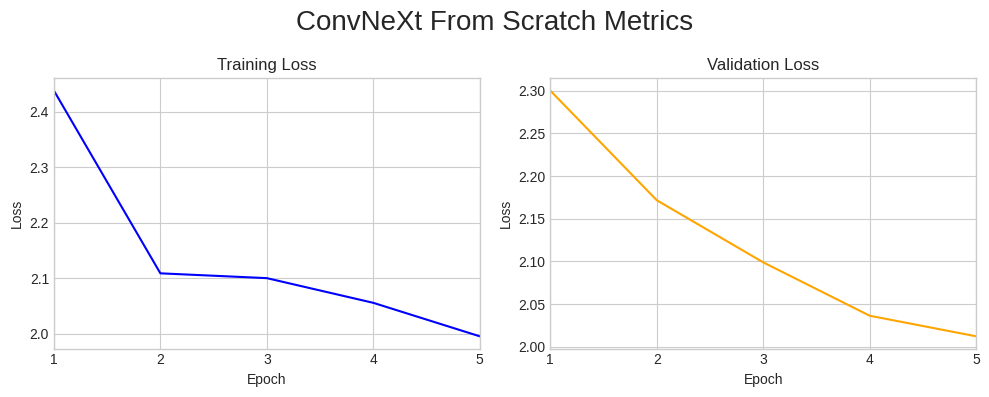

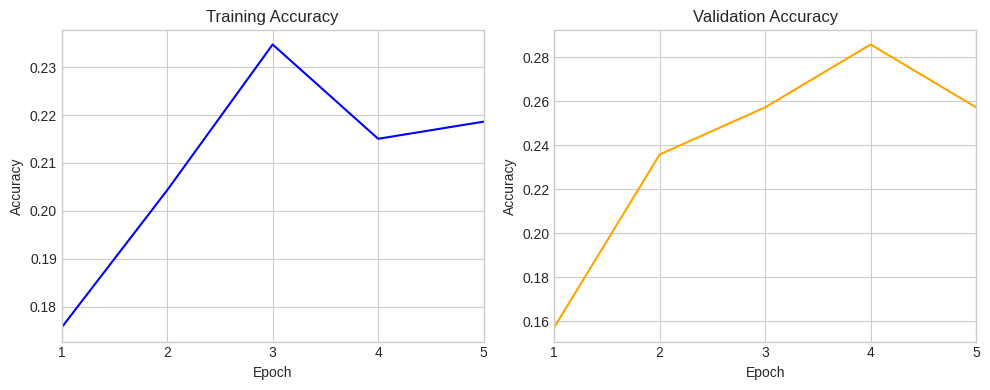

In [ ]:
# Load a ConvNeXt model with uninitialized weights
uninitialized_convnext = convnext_base(weights=None)

# Replace the final classification layer of the ConvNeXt
uninitialized_convnext = replace_final_convnext_linear_layer(uninitialized_convnext)

# Initialize the optimizer
optimizer = AdamW(uninitialized_convnext.parameters(), lr=5e-5)

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Train your model for 5 epochs
num_epochs = 5
unintialized_train_losses, unintialized_val_losses, unintialized_train_accuracies, unintialized_val_accuracies = train_image_classifier(uninitialized_convnext, optimizer, criterion, device, num_epochs, spectrogram_train_dataloader, spectrogram_test_dataloader)

# Plot the metrics
plot_metrics(unintialized_train_losses, unintialized_val_losses, unintialized_train_accuracies, unintialized_val_accuracies, num_epochs, title="ConvNeXt From Scratch Metrics")

## Output: Model reached **> 0.20** training accuracy after **5 epochs.**

<!-- END QUESTION -->

## Train a ConvNeXt with a Frozen Backbone ##

Now, training a ConvNeXt model using pretrained weights, but only the classifier head will be updated. **The backbone will be "frozen" and act as a fixed feature extractor.**

<!-- BEGIN QUESTION -->



Epoch 1: Training loss = 2.10173323419359	Train accuracy = 0.27598566308243727
Epoch 1: Validation loss = 1.8981988430023193	Validation accuracy = 0.37142857142857144
Epoch 2: Training loss = 1.7619408633973863	Train accuracy = 0.449820788530466
Epoch 2: Validation loss = 1.6304472446441651	Validation accuracy = 0.45714285714285713
Epoch 3: Training loss = 1.5880101985401578	Train accuracy = 0.507168458781362
Epoch 3: Validation loss = 1.5110834836959839	Validation accuracy = 0.5571428571428572
Epoch 4: Training loss = 1.466655393441518	Train accuracy = 0.521505376344086
Epoch 4: Validation loss = 1.4187890529632567	Validation accuracy = 0.5928571428571429
Epoch 5: Training loss = 1.4144912362098694	Train accuracy = 0.5394265232974911
Epoch 5: Validation loss = 1.3614513397216796	Validation accuracy = 0.5714285714285714
==================== Final Metrics ====================
Final training loss: 1.41449	Final training accuracy = 0.53943
Final validation loss: 1.36145	Final validation a

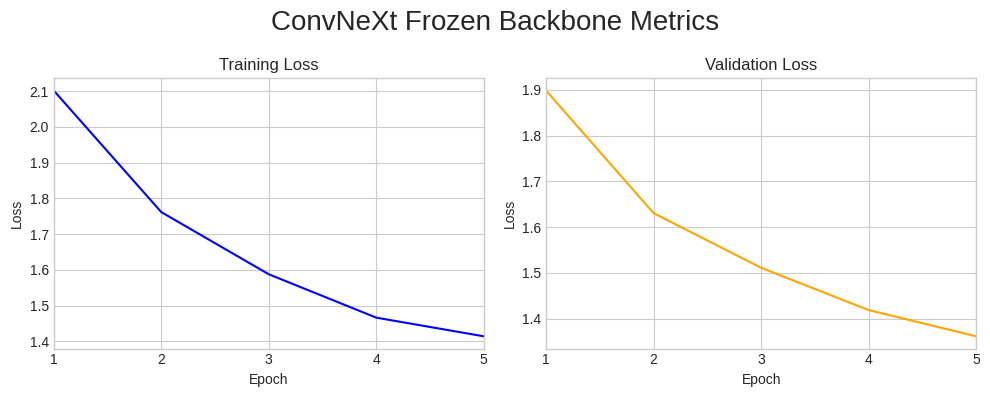

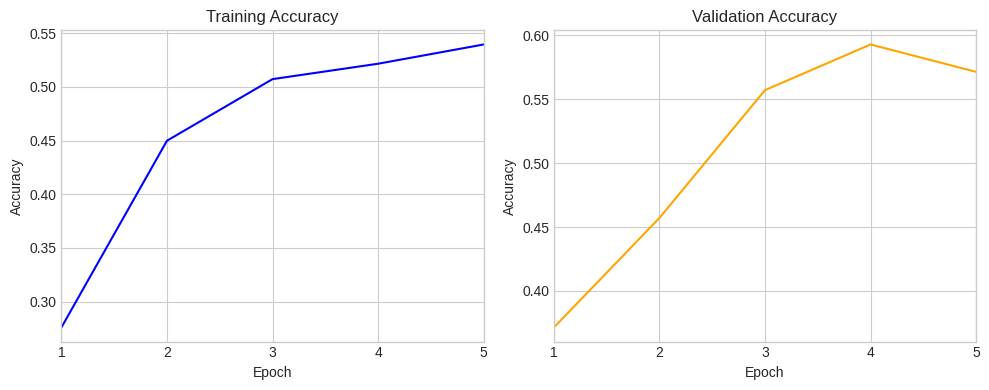

In [ ]:
# Load a ConvNeXt model with pretrained weights
frozen_backbone = convnext_base(weights=ConvNeXt_Base_Weights.IMAGENET1K_V1)

# Replace the final classification layer of the ConvNeXt
frozen_backbone = replace_final_convnext_linear_layer(frozen_backbone)

# Freeze the ConvNeXt's backbone
for name, param in frozen_backbone.named_parameters():
   if "classifier" not in name: # Freeze any non-classifier layers
       param.requires_grad = False

# nitialize the optimizer
optimizer = AdamW(frozen_backbone.parameters(), lr=1e-3)

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Train your model for 5 epochs
num_epochs = 5
frozen_bb_train_losses, frozen_bb_val_losses, frozen_bb_train_accuracies, frozen_bb_val_accuracies = train_image_classifier(frozen_backbone, optimizer, criterion, device, num_epochs, spectrogram_train_dataloader, spectrogram_test_dataloader)

# Plot the metrics
plot_metrics(frozen_bb_train_losses, frozen_bb_val_losses, frozen_bb_train_accuracies, frozen_bb_val_accuracies, num_epochs, title="ConvNeXt Frozen Backbone Metrics")

## Output: Model reached **> 0.50** training accuracy after **5 epochs.**

<!-- END QUESTION -->

## Train a ConvNeXt with All Layers Unfrozen

**Lastly, I use ConvNeXt pretrained on ImageNet, but allowing all model layers, including the backbone and the classification head, to update during training.** This is called full finetuning and usually achieves the best adaptation to our data when we have enough examples.


Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:01<00:00, 254MB/s]


Epoch 1: Training loss = 2.102017833126916	Train accuracy = 0.25806451612903225
Epoch 1: Validation loss = 1.734777069091797	Validation accuracy = 0.45714285714285713
Epoch 2: Training loss = 1.4055212371879153	Train accuracy = 0.5931899641577061
Epoch 2: Validation loss = 0.9972543954849243	Validation accuracy = 0.7
Epoch 3: Training loss = 0.7961745891306136	Train accuracy = 0.7544802867383512
Epoch 3: Validation loss = 0.6259361445903778	Validation accuracy = 0.8142857142857143
Epoch 4: Training loss = 0.49573418084118104	Train accuracy = 0.8548387096774194
Epoch 4: Validation loss = 0.43694663643836973	Validation accuracy = 0.8428571428571429
Epoch 5: Training loss = 0.31845706121789086	Train accuracy = 0.921146953405018
Epoch 5: Validation loss = 0.45153807401657103	Validation accuracy = 0.8142857142857143
==================== Final Metrics ====================
Final training loss: 0.31846	Final training accuracy = 0.92115
Final validation loss: 0.45154	Final validation accuracy =

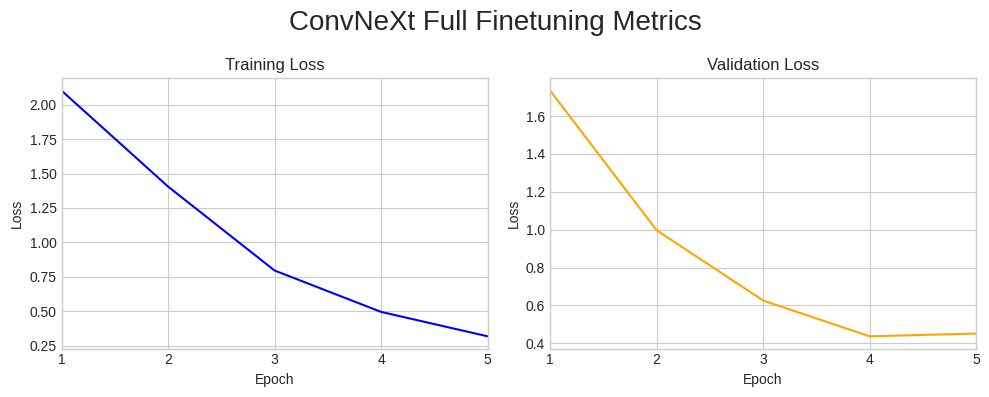

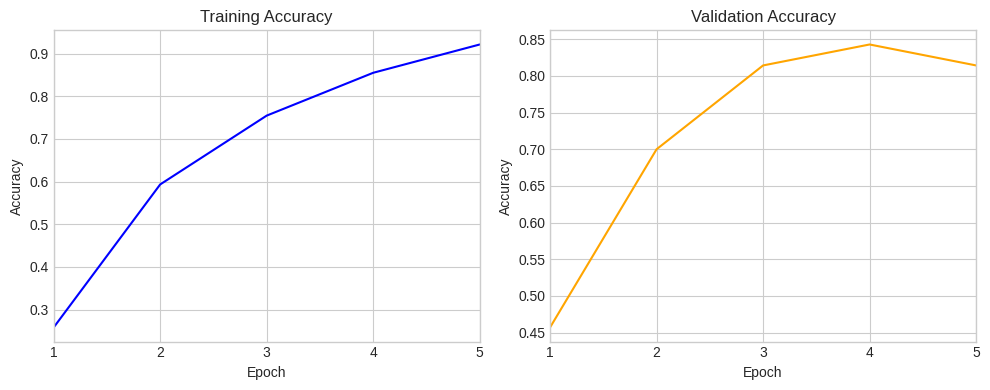

In [ ]:
# Load a ConvNeXt model with pretrained weights
unfrozen_convnext = convnext_base(weights=ConvNeXt_Base_Weights.IMAGENET1K_V1)

# Replace the final classification layer of the ConvNeXt
unfrozen_convnext = replace_final_convnext_linear_layer(unfrozen_convnext)

# Make sure all the parameters are trainable
for param in unfrozen_convnext.parameters():
  param.requires_grad = True

# Initialize the optimizer
optimizer = AdamW(unfrozen_convnext.parameters(), lr=8e-5)

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Train for 5 epochs
num_epochs = 5
unfrozen_train_losses, unfrozen_val_losses, unfrozen_train_accuracies, unfrozen_val_accuracies = train_image_classifier(unfrozen_convnext, optimizer, criterion, device, num_epochs, spectrogram_train_dataloader, spectrogram_test_dataloader)

# Plot the metrics
plot_metrics(unfrozen_train_losses, unfrozen_val_losses, unfrozen_train_accuracies, unfrozen_val_accuracies, num_epochs, title="ConvNeXt Full Finetuning Metrics")

## Model reached **> 0.90** training accuracy after **5 epochs.**

<!-- END QUESTION -->

## QueComparing Results of Different Fine-tuning Paradigms

Which of the 3 fine-tuning approaches was the most effective? Why? Can you think of some disadvantages of this approach, and some scenarios where we might want to use the other 2 approaches instead?


## Comparing Results of Different Fine-tuning Paradigms

FULL fine tuning on a pre-trained ConvNeXt was by far the most effective. Because every layer adapts to the new dataset, earlier features (defined in earler layers) can shift towards the dataset you are currently working with.

Some disadvantages of full fine tuning is that it takes significantly more computational power and needs longer training time. Another disadvantage is that full finetuning can overfit the model to your training data. Also "catastrophic forgetting" poses a risk.

For example, if you need a fast and computationally cheap model, it is better to use a frozen backbone. Or if you have an extremely large dataset and the domain is completely different from the original target of the pre-trained model, it may be better to train a new model from scratch (instead of full fine-tuning a previously complete model).

<!-- END QUESTION -->

## Listening to the Classifier's Predictions!

In [ ]:
# Pick an audio file to listen to and save it to the `audio_file` variable
audio_file = '/content/drive/MyDrive/cs189/hw/hw4/data/fold1_train/101415-3-0-2.wav'
if IS_COLAB:
    from IPython.display import Audio, display
    display(Audio(audio_file, autoplay=False))
else:
    import pygame
    pygame.mixer.init()
    pygame.mixer.music.load(audio_file)
    pygame.mixer.music.play()
    while pygame.mixer.music.get_busy():
        pygame.time.Clock().tick(10)

try:
    # Load the .wav audio file
    waveform, sample_rate = torchaudio.load(audio_file)

    # Average the channels to create a single mono channel
    waveform = waveform.mean(dim=0, keepdim=True)

    # Generate a spectrogram
    spec = spectrogram_transform(waveform)

    # Resize the spectrogram into the shape (1 x 224 x 224)
    spec = resize_transform(spec)

    # Repeat the spectrogram 3 times to have 3 channels
    spec = spec.repeat(3, 1, 1)

    # Add a batch dimension
    spec = spec.unsqueeze(0)

    # Move the input to the right device and cast it to the right dtype
    spec = spec.to(device, dtype=torch.float)

    # Let the model's outputs
    y_hat = unfrozen_convnext(spec)

    # Find the class with the highest output score
    _, pred = torch.max(y_hat, 1)

    # Look up the class label of the model's prediction
    predicted_class = class_id_to_sound[pred.item()]

    # Parse the audio file's name to get the true class ID and the true class label
    true_class_id = int(audio_file.split('-')[1])
    true_class = class_id_to_sound[true_class_id]

    print(f"Predicted class: {predicted_class}")
    print(f"True class: {true_class}")
except Exception as e:
    print(f'Error processing {audio_file}: {e}')


Predicted class: dog_bark
True class: dog_bark


<!-- END QUESTION -->

## Sound Classification Kaggle Competition

In [ ]:
# Unzip the test data to data/urbansound8k_test. This may take a few minutes!
!unzip -o -q /content/drive/MyDrive/cs189/hw/hw4/data/urbansound8k_test/urbansound8k_test.zip -d /content/drive/MyDrive/cs189/hw/hw4/data/urbansound8k_test

In [ ]:
def generate_urbansound8k_test_predictions(model):
    """
    Generates predictions for the UrbanSound8K test set using the specified model.

    Loads the test metadata from 'urbansound8k_test.csv', applies necessary transforms
    to each audio sample in the 'urbansound8k_test' directory, and creates a test dataset.
    Runs the model in evaluation mode to predict class labels for each test spectrogram.
    Predictions are saved to 'urbansound8k_test_predictions.csv' with columns 'ID' and 'class',
    where 'ID' is taken from the test CSV.

    Args:
        model (torch.nn.Module): Trained PyTorch model for UrbanSound8K classification.

    Outputs:
        urbansound8k_test_predictions.csv: CSV file with index column 'ID' and a 'class' column
        containing the predicted class for each audio sample in the test set.
    """
    # Load the UrbanSound8k test CSV with IDs
    test_df = pd.read_csv('urbansound8k_test.csv')

    # Define the resize transform (same as used for training)
    resize_transform = torchvision.transforms.Resize(size=[224, 224])

    # Create test dataset with return_targets=False
    test_dataset = SpectrogramDataset(
        audio_dir='/content/drive/MyDrive/cs189/hw/hw4/data/urbansound8k_test',
        return_targets=False,
        transforms=resize_transform
    )

    # Make predictions
    model.eval()
    predictions = []

    with torch.no_grad():
        for i in range(len(test_dataset)): # Iterate through all samples in our Dataset
            spec = test_dataset[i]

            if spec is None:
                predictions.append(-1) # Handle cases where spectrogram generation failed
                continue

            # Add batch dimension and move to device
            spec = spec.unsqueeze(0).to(device) # shape: (1, 224, 224)

            # Make prediction
            output = model(spec)
            pred_class = torch.argmax(output, dim=1).item()
            predictions.append(pred_class)

    # Create predictions dataframe
    predictions_df = pd.DataFrame({
        'ID': test_df['ID'],
        'class': predictions
    }).set_index('ID')

    predictions_df.to_csv('urbansound8k_test_predictions.csv', index=True) # Generates a csv with 2 columns: ID and class
    print("Submissions saved to urbansound8k_test_predictions.csv")

In [ ]:
# scheduler
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

Epoch 1: Training loss = 1.6959516803423564	Train accuracy = 0.4103942652329749
Epoch 1: Validation loss = 1.6098498106002808	Validation accuracy = 0.4142857142857143
Epoch 2: Training loss = 0.8363762762811449	Train accuracy = 0.7222222222222222
Epoch 2: Validation loss = 0.7725829482078552	Validation accuracy = 0.7071428571428572
Epoch 3: Training loss = 0.689779433939192	Train accuracy = 0.7867383512544803
Epoch 3: Validation loss = 0.8827583074569703	Validation accuracy = 0.6714285714285714
Epoch 4: Training loss = 0.6115456653965844	Train accuracy = 0.8064516129032258
Epoch 4: Validation loss = 1.0488036513328551	Validation accuracy = 0.6357142857142857
Epoch 5: Training loss = 0.5631461466352145	Train accuracy = 0.8243727598566308
Epoch 5: Validation loss = 0.6305960416793823	Validation accuracy = 0.7714285714285715
Epoch 6: Training loss = 0.3203275149895085	Train accuracy = 0.8906810035842294
Epoch 6: Validation loss = 0.555674421787262	Validation accuracy = 0.8357142857142857


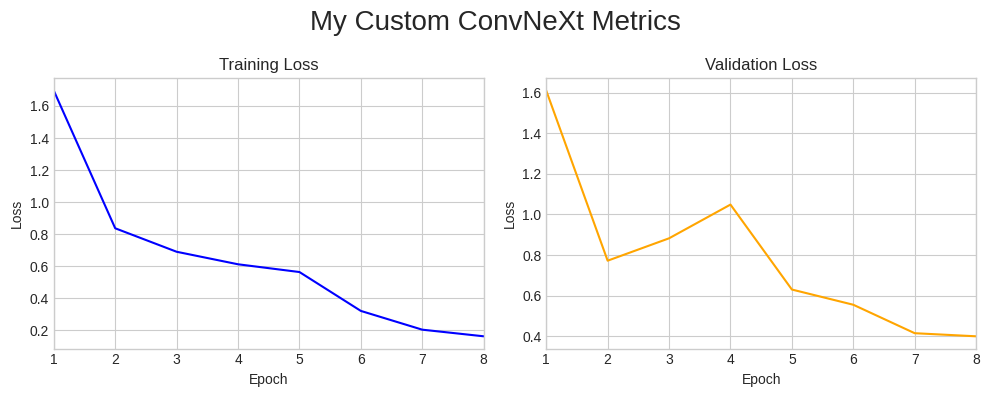

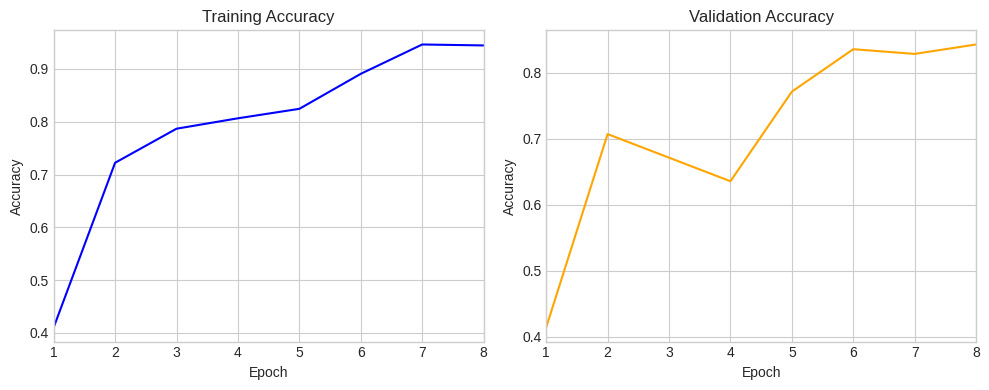

In [ ]:
# My ConvNeXt: larger classification head, full finetuning, and a cosine scheduler
unfrozen_convnext = convnext_base(weights=ConvNeXt_Base_Weights.IMAGENET1K_V1)
unfrozen_convnext = replace_final_convnext_linear_layer(unfrozen_convnext, 10)

# To be safe, manually unfreeze all layers
for param in unfrozen_convnext.parameters():
  param.requires_grad = True

num_epochs = 8
optimizer = AdamW(unfrozen_convnext.parameters(), lr=6e-4, weight_decay=2e-4)
criterion = nn.CrossEntropyLoss()

# Cosine: T_0 =num_epochs "one cycle is the number of epochs", T_mult=2 "next cycle doubles"
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=num_epochs, T_mult=4, eta_min=5e-7)

unfrozen_tl, unfrozen_vl, unfrozen_ta, unfrozen_va = train_image_classifier(unfrozen_convnext, optimizer, criterion, device, num_epochs,
                                                                            spectrogram_train_dataloader, spectrogram_test_dataloader, scheduler)

# My plot
plot_metrics(unfrozen_tl, unfrozen_vl, unfrozen_ta, unfrozen_va, num_epochs, title="My Custom ConvNeXt Metrics")

In [ ]:

def generate_urbansound8k_test_predictions(model):
    """
    Generates predictions for the UrbanSound8K test set using the specified model.
    Ensures predictions are matched to the correct numeric file IDs.
    """
    # 1. Load the Test CSV (We use this just to get the list of expected IDs if needed,
    # but primarily we will build a new dataframe from our predictions)
    test_df = pd.read_csv('urbansound8k_test.csv')

    # 2. Define Transform
    resize_transform = torchvision.transforms.Resize(size=[224, 224])

    # 3. Create Dataset
    # We assume SpectrogramDataset loads files from the directory.
    test_dir = '/content/drive/MyDrive/cs189/hw/hw4/data/urbansound8k_test'
    test_dataset = SpectrogramDataset(
        audio_dir=test_dir,
        return_targets=False,
        transforms=resize_transform
    )

    dataset_file_list = []
    if hasattr(test_dataset, 'files'):
        dataset_file_list = test_dataset.files
    elif hasattr(test_dataset, 'file_paths'):
        dataset_file_list = test_dataset.file_paths
    else:
        # Fallback: If we can't access the internal list, we must trust
        # that the dataset loaded os.listdir order and replicate it to match.
        print("Warning: Could not find .files attribute in Dataset. Assuming os.listdir order.")
        dataset_file_list = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith('.wav')]
        # It is crucial this sort matches however the Dataset class sorted them internally
        dataset_file_list = sorted(dataset_file_list)


    # 4. Make Predictions
    model.eval()
    results = [] # Store dictionaries: {'ID': 123, 'class': 5}

    print(f"Running inference on {len(test_dataset)} files...")

    with torch.no_grad():
        for i in range(len(test_dataset)):
            spec = test_dataset[i]

            if spec is None:
                continue

            # Add batch dimension and move to device
            spec = spec.unsqueeze(0).to(device)

            # Predict
            output = model(spec)
            pred_class = torch.argmax(output, dim=1).item()

            # --- MATCHING LOGIC ---
            # Get the filename corresponding to this specific index i
            full_path = dataset_file_list[i]

            # Extract the ID from the filename (e.g., "/path/to/5.wav" -> "5")
            filename = os.path.basename(full_path) # "5.wav"
            file_id = int(os.path.splitext(filename)[0]) # 5

            results.append({
                'ID': file_id,
                'class': pred_class
            })

    # 5. Create DataFrame from the matched results
    predictions_df = pd.DataFrame(results)

    # Sort numerically by ID so it matches the submission format expected
    predictions_df = predictions_df.sort_values(by='ID')

    # Set ID as index
    predictions_df = predictions_df.set_index('ID')

    # 6. Save
    predictions_df.to_csv('urbansound8k_test_predictions.csv', index=True)
    print("Submissions saved to urbansound8k_test_predictions.csv")

    # Optional: Preview
    print(predictions_df.head())

Screenshot 2026-03-06 at 2.33.45 PM.heic

# **My accuracy on test data was 94%!**

Testing my model on unseen data = "Public Score"



---



*By Hana Kozuka*

*UC Berkeley*
*Data Science* | *Business and Industrial Analytics*